# Day-ahead vs imbalance — the analysis, step by step

One trade: take a position in the OMIE day-ahead auction, close it in the REE
imbalance market. The P&L of one MWh is exactly the spread, signed by the
direction — so the entire problem is forecasting `imbalance_price - da_price`.

This notebook walks the argument in the order it was actually discovered.

In [1]:
import sys
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent
sys.path.insert(0, str(ROOT / "src"))
pd.set_option("display.width", 180, "display.max_columns", 30)

from omie_imbalance import backtest as bt
from omie_imbalance import data, features, information, plots, risk
from omie_imbalance.strategy import StrategyParams

df, quality = data.load(ROOT / "data" / "raw" / "market_data.csv")
print(quality)

2408 hourly rows over 101 days, 2024-01-01 to 2024-04-10
  missing hours in the calendar : 1
  duplicated timestamps         : 0
  days without 24 hours         : {'2024-03-31': 23, '2024-04-10': 9}


## 1. The tail, before anything else

The spread is not close to Gaussian. Any summary that leads with the mean is
describing a different distribution from the one we have to trade.

In [2]:
tails = data.tail_report(df)
print(f"mean {tails.attrs['mean']:+.2f}   median {tails.attrs['median']:+.2f}   std {tails.attrs['std']:.1f}")
print(f"worst hour {tails.attrs['worst']:,.0f}   best hour {tails.attrs['best']:,.0f}")
print(f"worst 1% of hours carry {tails.attrs['share_of_abs_sum_in_worst_1pct']:.1%} of the absolute P&L")
tails

mean +0.33   median +29.75   std 282.5
worst hour -4,713   best hour 8,171
worst 1% of hours carry 21.8% of the absolute P&L


,quantile,value
0,0.001,-3894.794335
1,0.010,-373.999815
2,0.050,-73.633850
3,0.250,-38.436000
4,0.500,29.750925
5,0.750,55.052037
6,0.950,86.989328
7,0.990,138.900776
8,0.999,893.820240


The median says *buy*. The mean says *nothing*. That gap is a tail, and it is
the reason "maximise profit" is the wrong objective for this problem.

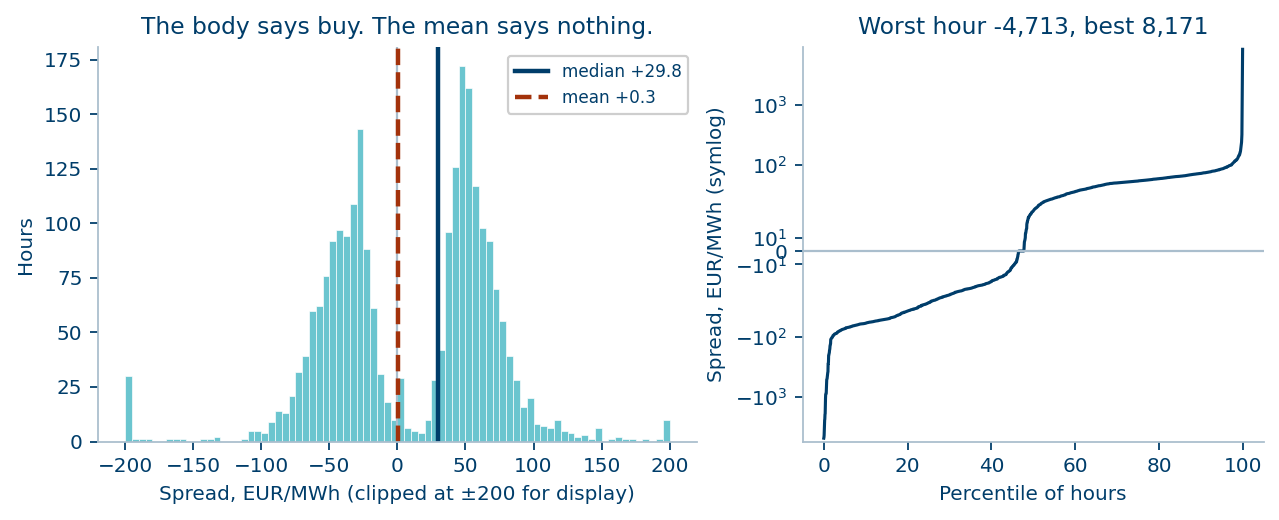

In [3]:
plots.spread_distribution(df, ROOT / "reports/figures/f1_spread_distribution.png")
from IPython.display import Image
Image(str(ROOT / "reports/figures/f1_spread_distribution.png"))

## 2. The finding the project rests on

Does the sign of the system imbalance determine the sign of the spread?

In [4]:
data.sign_agreement(df).to_frame("value")

,value
P(spread>0 | system short),0.997619
P(spread>0 | system long),0.000000
P(spread>0) unconditional,0.522010
median spread | system short,54.208585
median spread | system long,-39.829000
n short,1260.000000
n long,1148.000000


It does, almost exactly. Under single imbalance pricing this is close to
mechanical: a short system clears the imbalance price above the day-ahead price,
a long system clears it below.

**Consequence.** Forecasting the spread direction *is* forecasting the system
direction. So the model is two-stage — a classifier for direction, a regression
for size that takes the classifier's probability as an input — and the classifier
carries all the directional risk.

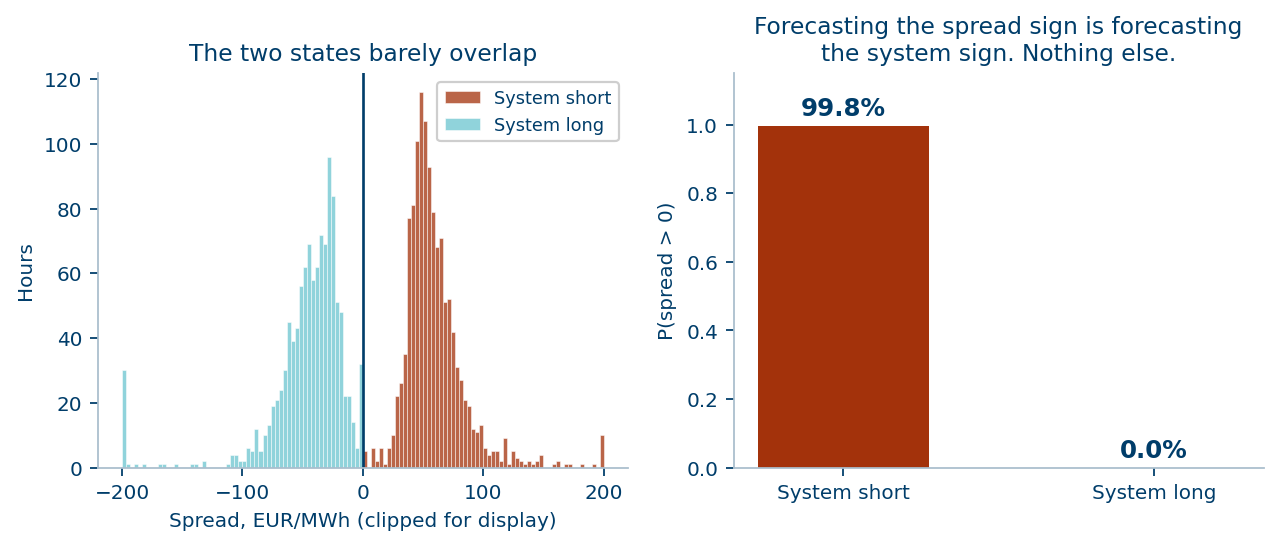

In [5]:
plots.sign_relationship(df, ROOT / "reports/figures/f2_sign_relationship.png")
Image(str(ROOT / "reports/figures/f2_sign_relationship.png"))

## 3. The constraint that decides everything: when do we have to decide?

The day-ahead auction closes at 12:00 on D-1 and covers all 24 hours of day D.
Two things follow, and skipping either is how this kind of backtest produces a
Sharpe ratio that does not exist:

- the day-ahead price of day D is **not** an input — it is the outcome of the
  auction we are bidding into;
- imbalance outcomes are published after delivery, so the freshest legitimate
  observation is 13 hours old for hour 0 and **36 hours old for hour 23**.

In [6]:
info = information.InformationSet()
print(f"minimum lag safe for every hour of the delivery day: {info.min_safe_lag()} h\n")
info.describe().head(6)

minimum lag safe for every hour of the delivery day: 36 h



,delivery_hour,decision_time,last_observable,lag_hours
0,0,2024-01-01 12:00:00,2024-01-01 11:00:00,13
1,1,2024-01-01 12:00:00,2024-01-01 11:00:00,14
2,2,2024-01-01 12:00:00,2024-01-01 11:00:00,15
3,3,2024-01-01 12:00:00,2024-01-01 11:00:00,16
4,4,2024-01-01 12:00:00,2024-01-01 11:00:00,17
5,5,2024-01-01 12:00:00,2024-01-01 11:00:00,18


## 4. Is the system sign predictable at that horizon?

Persistence first, as the honest benchmark any model has to beat.

In [7]:
s = df["system_long"]
rows = [{"lag_hours": L, "persistence_accuracy": float((s == s.shift(L)).mean()),
         "usable_at_gate_closure": L >= info.min_safe_lag()} for L in (1, 2, 3, 24, 36, 48, 168)]
pd.DataFrame(rows).assign(base_rate=max(s.mean(), 1 - s.mean()))

,lag_hours,persistence_accuracy,usable_at_gate_closure,base_rate
0,1,0.793605,False,0.523256
1,2,0.716777,False,0.523256
2,3,0.661545,False,0.523256
3,24,0.604236,False,0.523256
4,36,0.504153,True,0.523256
5,48,0.561047,True,0.523256
6,168,0.469269,True,0.523256


One hour of persistence is worth 79% and is useless — we do not have it in
time. At the horizon we actually face, persistence is barely above the base rate.

Now the model, walk-forward, refitted daily.

In [8]:
cfg = bt.BacktestConfig(params=StrategyParams())
res_model = bt.run_model(df, cfg)
res_cal   = bt.run_model(df, bt.BacktestConfig(use_lags=False))

from sklearn.metrics import roc_auc_score
truth = df["system_long"].reindex(res_model.predictions.index)
print(f"AUC, full features    {roc_auc_score(truth, res_model.predictions.p_long):.3f}")
print(f"accuracy at 0.5       {((res_model.predictions.p_long > 0.5).astype(int) == truth).mean():.1%}")
print(f"base rate             {max(truth.mean(), 1 - truth.mean()):.1%}")

AUC, full features    0.577
accuracy at 0.5       54.5%
base rate             50.1%


**The classifier does not beat the base rate.** This is not a tuning problem.
The system imbalance at a 13-to-36 hour horizon is driven by forecast error in
wind, solar and demand, and none of those is in this dataset. That absence is
the result, and it is worth stating plainly rather than papering over with a
larger model.

## 5. What does survive: the daily shape

The clock is known a day ahead, and the clock carries the solar profile.

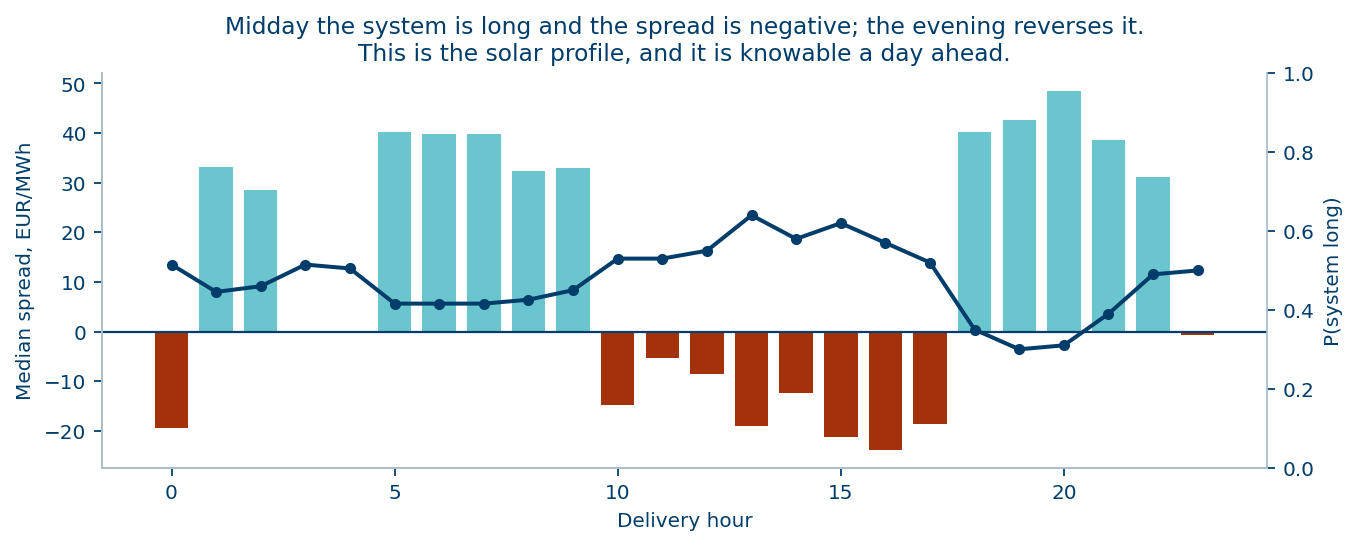

In [9]:
plots.hourly_shape(df, ROOT / "reports/figures/f3_hourly_shape.png")
Image(str(ROOT / "reports/figures/f3_hourly_shape.png"))

## 6. Backtest: everything against everything

Walk-forward, expanding window, refitted daily. Every strategy settles at the
true uncapped spread — the tail is never hidden from the P&L.

In [10]:
results = {
    "Always buy DA": bt.run_constant(df, +1, cfg),
    "Always sell DA": bt.run_constant(df, -1, cfg),
    "Two-stage model": res_model,
    "Two-stage, calendar only": res_cal,
    "Seasonal median": bt.run_seasonal(df, cfg),
    "Seasonal median, |edge|>=20": bt.run_seasonal(
        df, bt.BacktestConfig(params=StrategyParams(min_edge=20.0)), min_abs_median=20.0),
    "Oracle (system sign)": bt.run_oracle(df, cfg),
}
table = risk.compare({k: (v.pnl, v.position) for k, v in results.items()})
table[["share_traded", "mean", "median", "mean_ci_low", "mean_ci_high",
       "sharpe_ann", "cvar_5pct", "max_drawdown", "worst_hour"]].round(2)

,share_traded,mean,median,mean_ci_low,mean_ci_high,sharpe_ann,cvar_5pct,max_drawdown,worst_hour
Oracle (system sign),0.99,56.00,47.93,49.51,64.80,38.96,7.94,0.00,0.00
"Seasonal median, |edge|>=20",0.70,4.66,0.00,-1.59,10.60,5.63,-131.61,-3428.88,-1855.33
Seasonal median,0.97,5.93,18.43,-2.73,16.99,3.82,-146.51,-4258.98,-1855.33
Always buy DA,1.00,3.33,0.00,-6.42,12.14,2.14,-191.02,-4759.52,-4550.50
"Two-stage, calendar only",1.00,1.86,2.11,-4.94,7.80,1.20,-168.09,-5347.76,-4550.50
Two-stage model,1.00,-0.57,0.10,-9.17,6.54,-0.37,-174.08,-5439.11,-4550.50
Always sell DA,1.00,-3.33,0.00,-12.14,6.42,-2.14,-116.01,-9445.63,-1026.37


Three readings, in order of importance:

1. **Every implementable strategy has a 95% interval on its mean that contains
   zero.** With 101 days and this tail, nothing here is distinguishable from
   luck. The ranking is informative; the levels are not.
2. **A one-line seasonal baseline beats the machine learning model**, and
   removing the lagged features *improves* the model — they are noise.
3. **The gap to the oracle prices information.** 4.66 against 56.00: a real
   system-imbalance forecast is worth roughly twelve times the entire calendar
   edge. That is an argument for buying wind and demand data, not for a bigger
   classifier.

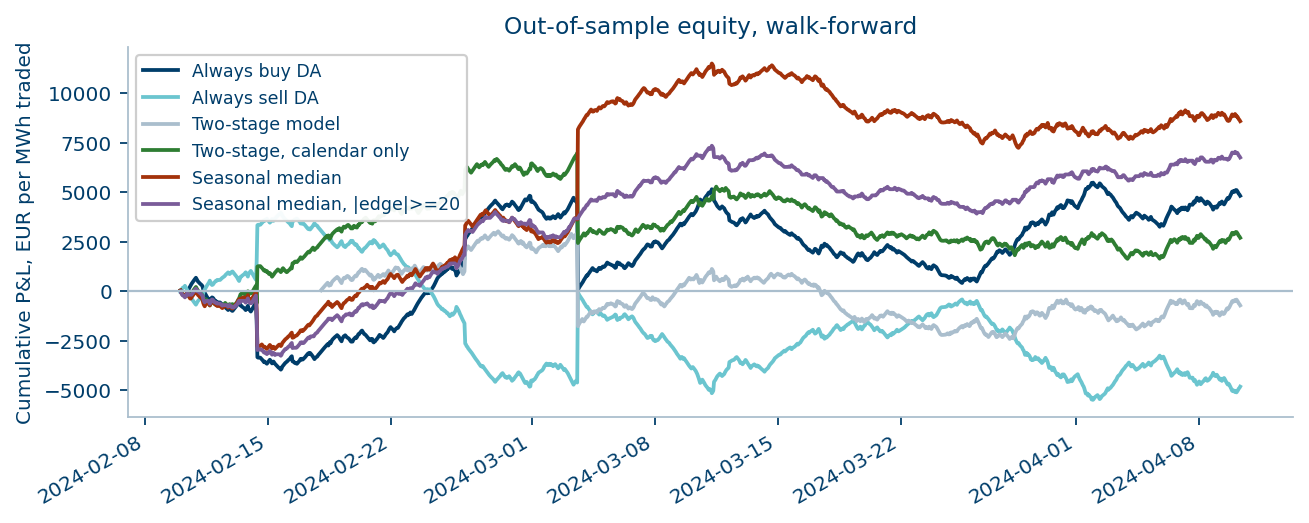

In [11]:
plots.equity_curves({k: v.pnl for k, v in results.items()},
                    ROOT / "reports/figures/f4_equity.png",
                    exclude=("Oracle (system sign)",))
Image(str(ROOT / "reports/figures/f4_equity.png"))

## 7. Risk, and why it is the same question as the metric

Judged on total profit or hit rate, *always buy the day-ahead* looks acceptable.
It also has a single hour costing −4,551 EUR/MWh. Standing down when the edge is
small is worth more than any feature in the model.

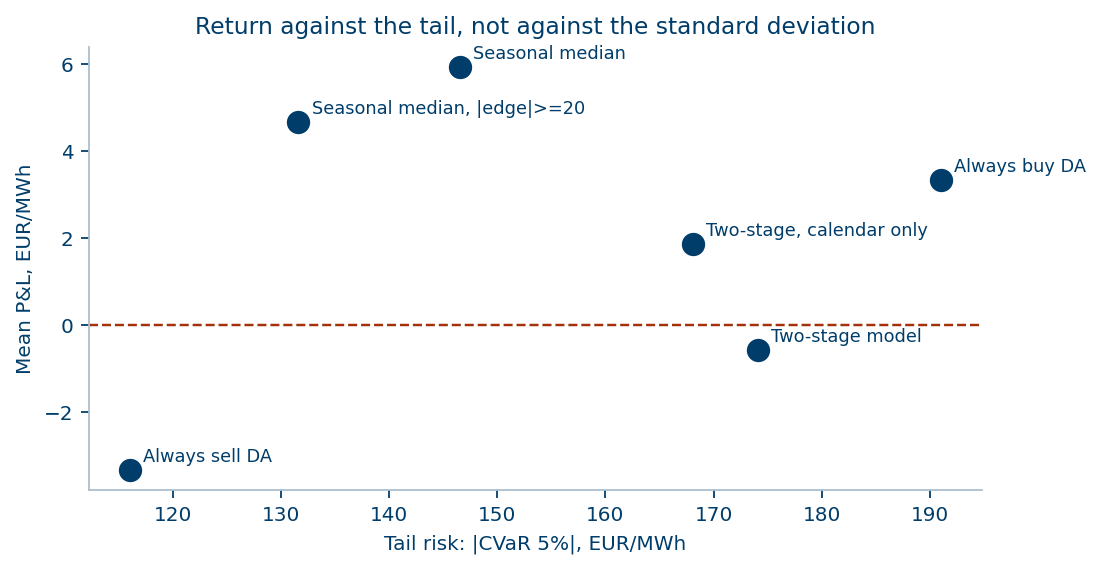

In [12]:
plots.risk_return(table, ROOT / "reports/figures/f5_risk_return.png",
                  exclude=("Oracle (system sign)",))
Image(str(ROOT / "reports/figures/f5_risk_return.png"))

In [13]:
best = results["Seasonal median, |edge|>=20"]
lo, hi = risk.bootstrap_mean_ci(best.pnl)
print(f"mean {best.pnl.mean():+.2f} EUR/MWh, 95% CI [{lo:+.2f}, {hi:+.2f}]")
print(f"CVaR 5%        {risk.cvar(best.pnl):+.1f}")
print(f"max drawdown   {risk.max_drawdown(best.pnl):+.0f}")
print(f"worst 1% of hours carry {risk.tail_concentration(best.pnl):.1%} of absolute P&L")

mean +4.66 EUR/MWh, 95% CI [-1.59, +10.60]
CVaR 5%        -131.6
max drawdown   -3429
worst 1% of hours carry 9.2% of absolute P&L


## Conclusion

The spread is a near-deterministic function of the system imbalance sign. That
sign is not forecastable from these four columns at the moment the day-ahead
decision has to be made. What remains is a calendar effect — the solar shape —
worth a few euros per MWh with a confidence interval that includes zero, and a
tail that decides the outcome more than the forecast does.

For a desk, the actionable conclusions are the second and third: **buy the
exogenous data that would make the sign forecastable**, and until then **size
small and stand down often**.